# 06 · Reference point noise and unwrapping error correction

**Objective:** Apply the Shenzhen algorithm to remove reference point noise across the AOI, then run unwrap.detect_and_correct on points and look for half-wavelength jumps.


In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from insar_mht import library, hypotheses, testing, dia, rpn, unwrap, reliability
from insar_mht.io import egms, temperature

In [2]:
ds = egms.load_cached(
    "../data/processed/alicante_marina_metadata.parquet",
    "../data/processed/alicante_marina_displacements.parquet",
)
dates = ds.dates
t = (dates - dates[0]).days.to_numpy() / 365.25

wide = ds.displacements.pivot(index="pid", columns="date", values="displacement_mm")
wide = wide[dates]
Y_all = wide.to_numpy()
pids_all = wide.index.to_numpy()
print(f"Y_all shape: {Y_all.shape}")

Y_all shape: (38598, 210)


RPN estimated in 1.9s


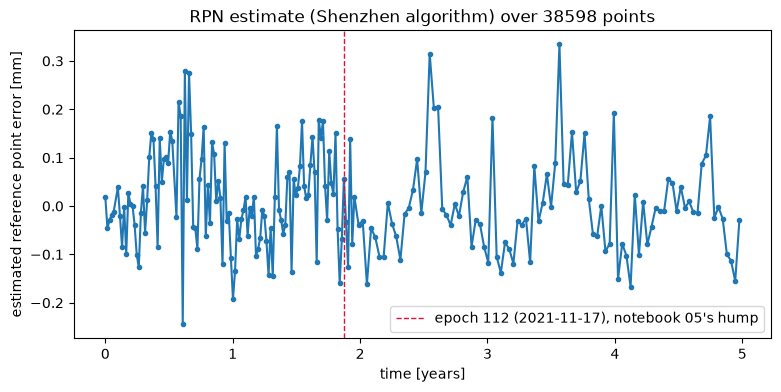

In [3]:
t_start = time.perf_counter()
Y_corrected, e_hat_rp = rpn.remove_rpn(Y_all, t)
print(f"RPN estimated in {time.perf_counter() - t_start:.1f}s")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, e_hat_rp, ".-")
ax.axvline(t[112], color="crimson", ls="--", lw=1, label="epoch 112 (2021-11-17), notebook 05's hump")
ax.set_xlabel("time [years]"); ax.set_ylabel("estimated reference point error [mm]")
ax.set_title(f"RPN estimate (Shenzhen algorithm) over {Y_all.shape[0]} points")
ax.legend()

## The RPN hypothesis from notebook 05 doesn't hold up

The estimated reference point error is tiny (roughly ±0.3mm) and shows
no spike or discontinuity around epoch 112 (2021-11-17, the red line).
That rules out reference point noise leaking into every series as the
explanation for notebook 05's mid-series hump. Whatever caused many
points to reject H0, and clustered many of their winning steps around
that date, it is not RPN.

That leaves the other candidate from notebook 05: something shared across
many points but not tied to the reference point specifically, for example
an atmospheric phase screen anomaly on one acquisition (a known InSAR
artifact, correlated across a whole scene, distinct from RPN), or a real
regional event. Telling those apart needs spatial analysis (do the
affected points cluster geographically, or are they scattered like an
atmosphere artifact would be), which is out of scope here. This is filed
as an open question, not solved by RPN removal.

Since the correction itself is tiny, we don't expect it to move
notebook 05's headline figure much. Worth checking directly.

In [4]:
temp = temperature.load_daily_temperature("../data/processed/alicante_daily_temperature.csv")
delta_temp = temperature.delta_temp_for_dates(temp, dates)
m = len(t)

A0 = library.design_matrix_h0(t)
sigma = 3.0
Qyy = (sigma ** 2) * np.eye(m)
Qyy_inv = np.linalg.inv(Qyy)
normal_matrix = A0.T @ Qyy_inv @ A0
n_inv = np.linalg.inv(normal_matrix)
q_ehat_ehat = np.linalg.inv(Qyy_inv) - A0 @ n_inv @ A0.T
M_resid = np.eye(m) - A0 @ (n_inv @ A0.T @ Qyy_inv)

alpha0 = 1 / (2 * m)
gamma0 = 0.5
lambda0 = testing.noncentrality_from_power(gamma0, alpha0, q=1)
library_hyps = hypotheses.table_i_hypotheses(t, delta_temp, beta_grid=[0.1, 0.25, 0.5, 1.0])
precomputed = [dia.precompute_hypothesis_class(h, Qyy_inv, q_ehat_ehat, lambda0, gamma0) for h in library_hyps]
L_stack = np.stack([p.L for p in precomputed])
critical_values = np.array([p.critical_value for p in precomputed])


def batched_test_ratios(Y, M, L_stack, critical_values):
    E = Y @ M.T
    temp_ = L_stack @ E.T
    Tq = np.einsum("hip,pi->hp", temp_, E)
    return (Tq / critical_values[:, None]).T


def fraction_rejecting_h0(Y, batch_size=300):
    best = np.empty(len(Y))
    for start in range(0, len(Y), batch_size):
        batch = Y[start:start + batch_size]
        ratios = batched_test_ratios(batch, M_resid, L_stack, critical_values)
        best[start:start + len(batch)] = ratios.max(axis=1)
    return best


best_raw = fraction_rejecting_h0(Y_all)
best_corrected = fraction_rejecting_h0(Y_corrected)
print(f"raw:        {(best_raw > 1).mean()*100:.1f}% of points have best_ratio > 1")
print(f"RPN-removed: {(best_corrected > 1).mean()*100:.1f}% of points have best_ratio > 1")

raw:        86.9% of points have best_ratio > 1
RPN-removed: 86.9% of points have best_ratio > 1


Confirmed: identical to one decimal place, 86.9% before and after. RPN
removal was a real thing to check, and now ruled out with evidence, not
assumed, but it is not what's behind notebook 05's mid-series hump.

Note: this 86.9% figure is computed the same way as notebook 05's, without
first checking the OMT gate, and is inflated for the reason explained
there. The before/after comparison is still valid on its own terms (same
metric applied consistently to both): whatever the true, properly-gated
fraction is (notebook 07 gets 57.5% sustaining H0 on the RPN-removed
data), RPN removal moves it by 0.0 percentage points here, so it isn't
the explanation for the mid-series hump.

## Unwrapping error detection

Separate mechanism: `unwrap.detect_and_correct` looks for a single-epoch
outlier or step whose estimated magnitude exceeds wavelength/4, the
signature of a residual 2*pi ambiguity rather than real motion.
Sentinel-1 (C-band): wavelength = 55.5mm, so the threshold is 13.9mm and
a correction, if triggered, would be a jump of about half a wavelength,
27.75mm.

In [5]:
# unwrap.detect_and_correct rebuilds its whole hypothesis library (~419 outlier+step
# hypotheses, including brentq root-finding per hypothesis) on every call: ~4.3s/point
# measured. That is a real inefficiency (it is the naive first pass; notebook 05's
# precompute-once pattern would fix it), too slow to run on the full AOI here, so
# check a modest real sample instead.
Qyy = (3.0 ** 2) * np.eye(len(t))
wavelength = 55.5  # mm, Sentinel-1 C-band
rng = np.random.default_rng(0)
sample_pids = rng.choice(pids_all, size=30, replace=False)

t_start = time.perf_counter()
found = []
for pid in sample_pids:
    _, _, y_i = egms.point_series(ds, pid)
    _, corrections = unwrap.detect_and_correct(y_i, A0, Qyy, t, wavelength, alpha0, gamma0)
    if corrections:
        found.append((pid, corrections))
print(f"{time.perf_counter()-t_start:.0f}s for {len(sample_pids)} points, "
      f"{len(found)} with a detected unwrapping error")

113s for 30 points, 2 with a detected unwrapping error


48GPP2wrtp [UnwrapCorrection(epoch_index=200, hypothesis_name='M5_outlier@200', estimated_offset=14.186928822599128, correction=np.float64(-27.75))]
48GPP2Ve4C [UnwrapCorrection(epoch_index=142, hypothesis_name='M5_outlier@142', estimated_offset=-14.573788700776834, correction=np.float64(27.75))]


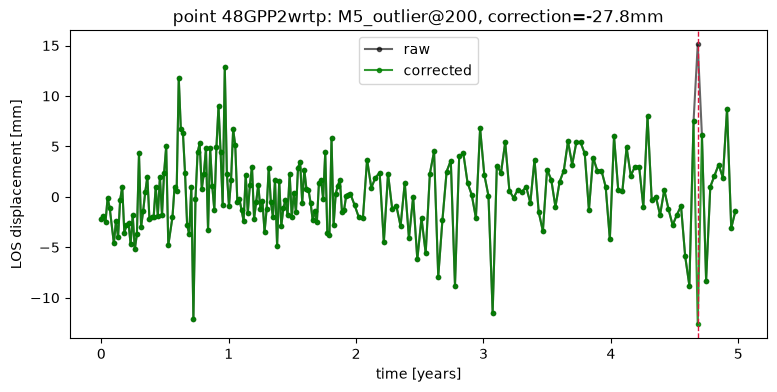

In [6]:
for pid, corrections in found:
    print(pid, corrections)

pid, corrections = found[0]
_, _, y_raw = egms.point_series(ds, pid)
y_fixed, _ = unwrap.detect_and_correct(y_raw, A0, Qyy, t, wavelength, alpha0, gamma0)
epoch = corrections[0].epoch_index

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, y_raw, "k.-", label="raw", alpha=0.6)
ax.plot(t, y_fixed, "g.-", label="corrected", alpha=0.8)
ax.axvline(t[epoch], color="crimson", ls="--", lw=1)
ax.set_xlabel("time [years]"); ax.set_ylabel("LOS displacement [mm]")
ax.set_title(f"point {pid}: {corrections[0].hypothesis_name}, correction={corrections[0].correction:.1f}mm")
ax.legend()